In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [15]:
readlines("../hBN_Optimization/hBN.out")

443-element Vector{String}:
 "--------------------------------------------------------------------------"
 "The library attempted to open the following supporting CUDA libraries,"
 "but each of them failed.  CUDA-aware support is disabled."
 "libcuda.so.1: cannot open shared object file: No such file or directory"
 "libcuda.dylib: cannot open shared object file: No such file or directory"
 "/usr/lib64/libcuda.so.1: cannot open shared object file: No such file or directory"
 "/usr/lib64/libcuda.dylib: cannot open shared object file: No such file or directory"
 "If you are not interested in CUDA-aware support, then run with"
 "--mca opal_warn_on_missing_libcuda 0 to suppress this message.  If you are interested"
 "in CUDA-aware support, then try setting LD_LIBRARY_PATH to the location"
 "of libcuda.so.1 to get passed this issue."
 "--------------------------------------------------------------------------"
 "--------------------------------------------------------------------------"
 ⋮
 

In [16]:
v1, v2, v3 = loadlattice("../hBN_Optimization/hBN.out")

3-element Vector{Vector{Float64}}:
 [2.5016789757300004, 0.0, 0.0]
 [-1.25083684198, 2.1665141392400002, 0.0]
 [0.0, 0.0, 21.16708]

In [3]:
readlines("../hBN_Optimization/hBN.ionpos")

4-element Vector{String}:
 "# Ionic positions in lattice coordinates:"
 "ion B  -0.000000000000000   0.000000000000000   0.000000000000000 0"
 "ion N   0.333333333333333   0.666666666666667   0.000000000000000 0"
 ""

In [17]:
## Rotation matrices in 2 and 3d (about z axis)
function rot(θ::Real)
    rot_matrix =[cos(θ) -sin(θ); sin(θ) cos(θ) ]
    return rot_matrix
end
function rot_3x3(θ::Real)
    rot_matrix =[cos(θ) -sin(θ) 0; sin(θ) cos(θ) 0; 0 0 1 ]
    return rot_matrix
end

rot_3x3 (generic function with 1 method)

In [26]:
11/13

0.8461538461538461

In [20]:
θ = acos(11/13)
unit_cell_array1=zeros(600, 600);
unit_cell_array2=zeros(600, 600);
for i in 1:600
    for j in 1:600
        unit_cell_array1[i, j] = in_wigner_seitz([v1, v2, v3], [(i-300)/(4*48), (j-300)/(4*48), 0], n=1)
        unit_cell_array2[i, j] = in_wigner_seitz([rot_3x3(θ)*v1, rot_3x3(θ)*v2, v3], [(i-300)*1/(4*48), (j-300)*1/(4*48), 0], n=1)
    end
end

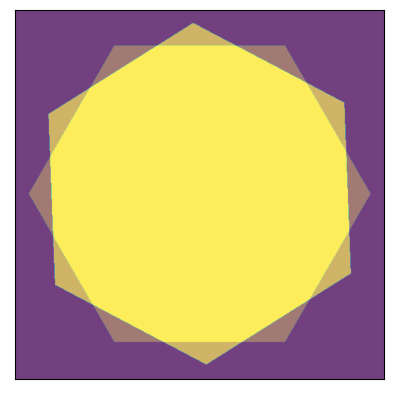

(Any[], Any[])

In [21]:
imshow(unit_cell_array1, alpha=0.5)
imshow(unit_cell_array2, alpha=0.5)
xticks(Float64[])
yticks(Float64[])

In [6]:
θ = acos(11/13)

for (ii, jj, kk, ll) in Tuple.(CartesianIndices(rand(11, 11, 11, 11)))
    i = ii-6
    j = jj-6
    k = kk-6
    l = ll-6
    a=[1, 0]; b=[-1/2, √3/2]
    c=rot(θ)*a; d=rot(θ)*b
    diff = i*a+b*j-c*k-d*l
    isapprox(sum(diff.^2), 0, atol=1e-6) || continue
    println(i, " ", j, " ", k, " ", l)
end

-1 -4 -3 -4
3 -1 1 -3
-4 -3 -4 -1
0 0 0 0
4 3 4 1
-3 1 -1 3
1 4 3 4


In [9]:
#We choose the linear combinations -2*a_1+a_2=-b_1+2*b_2, -a_1-3*a_2=-2*b_1-3*b_2, Let's verify that indeed works: 
a_1=[1, 0]; a_2=[-1/2, √3/2]
b_1=rot(θ)*a_1; b_2=rot(θ)*a_2
println(3*a_1-a_2-b_1+3*b_2)
println(-4*a_1-3*a_2+4*b_1+1*b_2)

[-4.440892098500626e-16, -2.220446049250313e-16]
[-1.1102230246251565e-16, 1.1102230246251565e-16]


In [14]:
c_1 = 3*a_1-a_2
c_2 = -4*a_1-3*a_2
cross([c_1..., 0] , [c_2..., 0])[3]/cross([a_1..., 0] , [a_2..., 0])[3]
sum([c_1..., 0].*[c_2..., 0])/sum([c_1..., 0].*[c_1..., 0])

-0.5

In [45]:
translations=[]
for i in -5:5
    for j in -5:5
        for k in -5:5
            for l in -5:5
                a, b = (layer1_to_superlattice*[2/3+k, 1/3+l]-layer2_to_superlattice*[2/3+i, 1/3+j])
                a < 0 && continue
                b < 0 && continue
                a >=1 && continue
                b >=1 && continue
                #println(a*sqrt(3), " ", b*3)
                a, b = round.([a, b], digits=5)
                [a, b] in translations && continue
                isequal([a,b], round.([1/3, 2/3], digits=5)) && println("$k $l $i $j")

                push!(translations, [a,b])
            end
        end
    end
end

-4 -5 -3 -2


In [46]:
layer1_to_superlattice*[2/3-4, 1/3-5]

2-element Vector{Float64}:
 0.6666666666666669
 1.3333333333333335

In [17]:
superlattice_to_layer1 = [3 -4; -1 -3]
superlattice_to_layer1_3x3 = [3 -4 0; -1 -3 0; 0 0 1]

superlattice_to_layer2 = [1 -4; -3 -1]
superlattice_to_layer2_3x3 = [1 -4 0; -3 -1 0; 0 0 1]

layer1_to_superlattice = inv(superlattice_to_layer1)
layer2_to_superlattice = inv(superlattice_to_layer2);

In [21]:
#The general method by which we create the ions
tot_ions = 0
for i in -20:20
    for j in -20:20
        iprime, jprime = round.(layer1_to_superlattice*[i, j], digits=5)
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion B $iprime $jprime 0 0" )
            tot_ions+=1
        end
        iprime, jprime = round.(layer1_to_superlattice*[i+1/3, j+2/3], digits=5)
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion N $iprime $jprime 0 0" )
            tot_ions+=1
        end
        iprime, jprime = round.(layer2_to_superlattice*[i, j], digits=5)
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion B $iprime $jprime \${d} 0" )
            tot_ions+=1
        end
        iprime, jprime = round.(layer2_to_superlattice*[i+1/3, j+2/3], digits=5)
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion N $iprime $jprime \${d} 0" )
            tot_ions+=1
        end
    end
end
println(tot_ions)

ion N 0.12821 0.94872 ${d} 0
ion N 0.41026 0.97436 0 0
ion N 0.82051 0.87179 ${d} 0
ion B 0.23077 0.92308 0 0
ion N 0.10256 0.74359 0 0
ion B 0.69231 0.92308 ${d} 0
ion N 0.51282 0.79487 ${d} 0
ion B 0.38462 0.84615 ${d} 0
ion N 0.20513 0.71795 ${d} 0
ion B 0.07692 0.76923 ${d} 0
ion N 0.64103 0.89744 0 0
ion N 0.89744 0.64103 ${d} 0
ion B 0.46154 0.84615 0 0
ion N 0.33333 0.66667 0 0
ion B 0.76923 0.69231 ${d} 0
ion N 0.58974 0.5641 ${d} 0
ion B 0.15385 0.61538 0 0
ion N 0.02564 0.4359 0 0
ion B 0.46154 0.61538 ${d} 0
ion N 0.28205 0.48718 ${d} 0
ion B 0.15385 0.53846 ${d} 0
ion N 0.87179 0.82051 0 0
ion N 0.97436 0.41026 ${d} 0
ion B 0.69231 0.76923 0 0
ion N 0.5641 0.58974 0 0
ion B 0.84615 0.46154 ${d} 0
ion N 0.66667 0.33333 ${d} 0
ion B 0.38462 0.53846 0 0
ion N 0.25641 0.35897 0 0
ion B 0.53846 0.38462 ${d} 0
ion N 0.35897 0.25641 ${d} 0
ion B 0.07692 0.30769 0 0
ion B 0.23077 0.30769 ${d} 0
ion N 0.05128 0.17949 ${d} 0
ion B 0.92308 0.69231 0 0
ion N 0.79487 0.51282 0 0
ion B 0

In [22]:
[4.727486978767153   -2.363743489383575    0.000000000000000;
 -0.000000000000000    4.094123819672498    0.000000000000000;
 0.000000000000000    0.000000000000000   40.000000000000000]*superlattice_to_layer1_3x3

3×3 Matrix{Float64}:
 16.5462   -11.8187   0.0
 -4.09412  -12.2824   0.0
  0.0        0.0     40.0

In [23]:
#Sanity check
rot_3x3(θ)*[4.727486978767153   -2.363743489383575    0.000000000000000;
 -0.000000000000000    4.094123819672498    0.000000000000000;
 0.000000000000000    0.000000000000000   40.000000000000000]*superlattice_to_layer2_3x3

3×3 Matrix{Float64}:
 16.5462   -11.8187   0.0
 -4.09412  -12.2824   0.0
  0.0        0.0     40.0

In [41]:
#Below, we provide two functions to write ions to files. The second function outputs the 

function write_moire_ions(tx::Real, ty::Real, io::IO)
    tot_ions = 0
    for i in -20:20
        for j in -20:20
            iprime, jprime = round.(layer1_to_superlattice*[i, j], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = round.(layer1_to_superlattice*[i+1/3, j+2/3], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = round.(layer2_to_superlattice*[i, j], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $(iprime+tx) $(jprime+ty) \${d} 0\n")
                tot_ions+=1
            end
            iprime, jprime = round.(layer2_to_superlattice*[i+1/3, j+2/3], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $(iprime+tx) $(jprime+ty) \${d} 0\n" )
                tot_ions+=1
            end
        end
    end
    (tot_ions != 52) && error("Wrong Number of Ions")
end

function write_moire_ions_reverse(tx::Real, ty::Real, io::IO)
    tot_ions = 0
    for i in -20:20
        for j in -20:20
            iprime, jprime = round.(layer1_to_superlattice*[i, j], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = round.(layer1_to_superlattice*[i+1/3, j+2/3], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = round.(layer2_to_superlattice*[i, j], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $(iprime+tx) $(jprime+ty) \${d} 0\n")
                tot_ions+=1
            end
            iprime, jprime = round.(layer2_to_superlattice*[i+1/3, j+2/3], digits=5)
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $(iprime+tx) $(jprime+ty) \${d} 0\n" )
                tot_ions+=1
            end
        end
    end
    (tot_ions != 52) && error("Wrong Number of Ions")
end

write_moire_ions_reverse (generic function with 1 method)

In [42]:
open("Moire13-0.333-0.666.ionpos", "w") do io
    write_moire_ions(1/3, 2/3, io)
end
open("Moire13-0.333-0.666-reverse.ionpos", "w") do io
    write_moire_ions_reverse(1/3, 2/3, io)
end

false

In [44]:
acosd(11/13)

32.204227503972035

In [27]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs"